# Benchmark the forward modeling code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import boule as bl
import harmonica as hm
import spherical

In [2]:
region = [-10, 10, 20, 60]
coordinates = vd.grid_coordinates(region, shape=(200, 200), extra_coords=bl.WGS84.mean_radius)
dipoles = vd.scatter_points(region, size=1000, random_state=10, extra_coords=bl.WGS84.mean_radius - 20e3)
dipole_moments = hm.magnetic_angles_to_vec(
    intensity=np.full_like(dipoles[0], 1e10),
    inclination=45,
    declination=-10,
)    

## Numba

In [5]:
%%time
b = spherical.dipole_magnetic_spherical(coordinates, dipoles, dipole_moments)

CPU times: user 1.27 s, sys: 0 ns, total: 1.27 s
Wall time: 130 ms


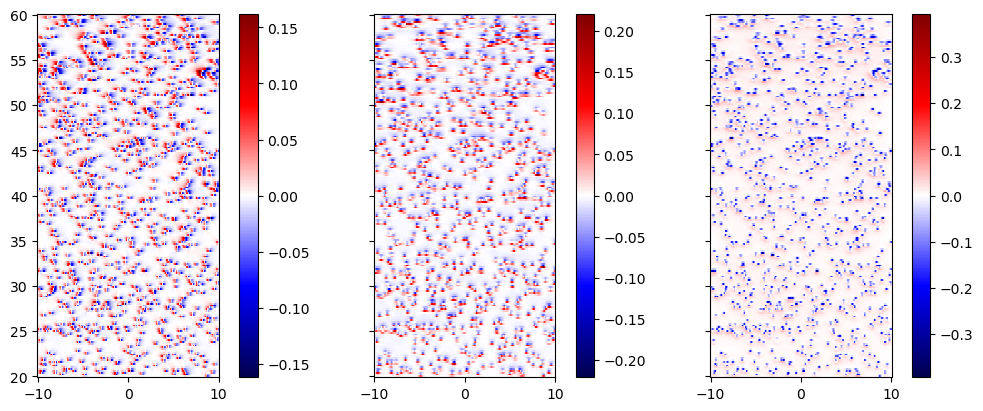

In [4]:
b = [i.reshape(coordinates[0].shape) for i in b]
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True, layout="constrained")
for ax, field in zip(axes, b):
    scale = vd.maxabs(field)
    tmp = ax.pcolormesh(*coordinates[:2], field, cmap="seismic", vmin=-scale, vmax=scale)
    fig.colorbar(tmp, ax=ax)
    ax.set_aspect("equal")

## No numba

In [3]:
%%time
b = spherical.dipole_magnetic_spherical(coordinates, dipoles, dipole_moments)

CPU times: user 2.28 s, sys: 0 ns, total: 2.28 s
Wall time: 2.27 s


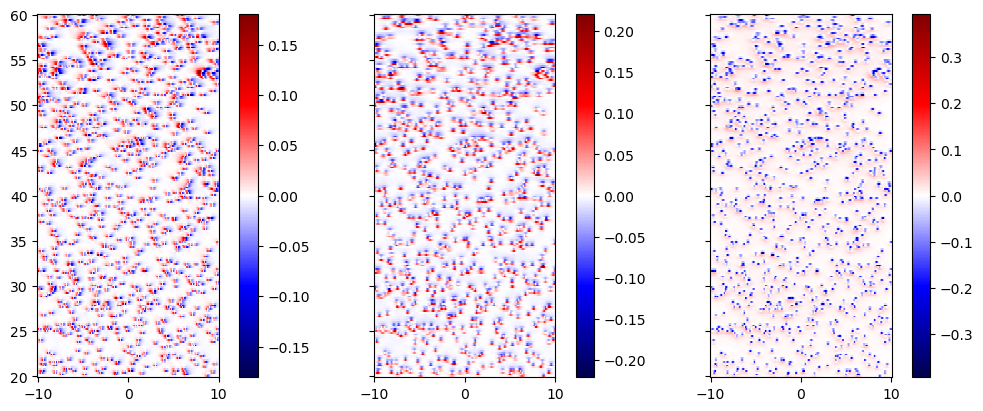

In [4]:
b = [i.reshape(coordinates[0].shape) for i in b]
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True, layout="constrained")
for ax, field in zip(axes, b):
    scale = vd.maxabs(field)
    tmp = ax.pcolormesh(*coordinates[:2], field, cmap="seismic", vmin=-scale, vmax=scale)
    fig.colorbar(tmp, ax=ax)
    ax.set_aspect("equal")

## Old

In [3]:
%%time
b = spherical.forward_modeling_spherical(coordinates, dipoles, dipole_moments)

CPU times: user 6.27 s, sys: 3.98 ms, total: 6.28 s
Wall time: 6.28 s


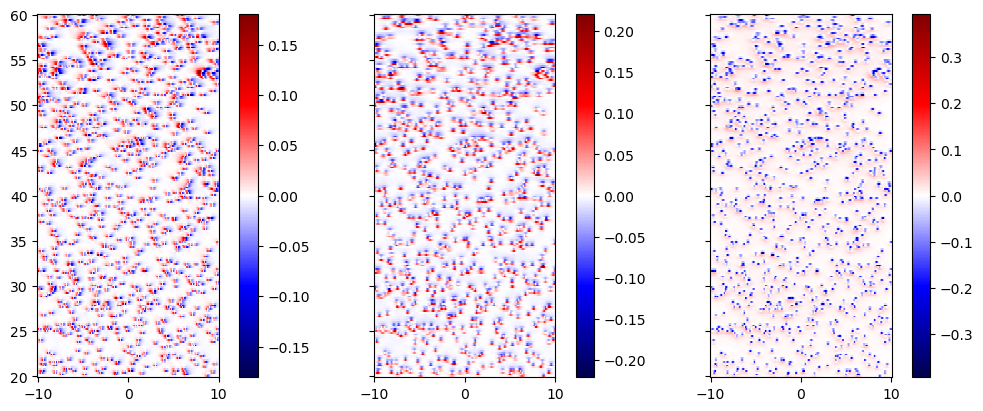

In [4]:
b = [i.reshape(coordinates[0].shape) for i in b]
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True, layout="constrained")
for ax, field in zip(axes, b):
    scale = vd.maxabs(field)
    tmp = ax.pcolormesh(*coordinates[:2], field, cmap="seismic", vmin=-scale, vmax=scale)
    fig.colorbar(tmp, ax=ax)
    ax.set_aspect("equal")